In [19]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [20]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [21]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

X = df[features].copy()
y = df["Survived"].copy()

print(X.head())
print(y.head())

   Pclass     Sex   Age  SibSp  Parch     Fare
0       3    male  22.0      1      0   7.2500
1       1  female  38.0      1      0  71.2833
2       3  female  26.0      0      0   7.9250
3       1  female  35.0      1      0  53.1000
4       3    male  35.0      0      0   8.0500
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [22]:
X["Sex"] = X["Sex"].map({"male": 0, "female": 1})
X["Age"].fillna(X["Age"].median(), inplace=True)

print(X.dtypes)



Pclass      int64
Sex         int64
Age       float64
SibSp       int64
Parch       int64
Fare      float64
dtype: object


C:\Users\thako\AppData\Local\Temp\ipykernel_10220\1493804537.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X["Age"].fillna(X["Age"].median(), inplace=True)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y.values,
    test_size=0.2,
    random_state=42,
    stratify=y.values
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (712, 6)
X_test: (179, 6)
y_train: (712,)
y_test: (179,)


In [24]:
X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train,
    dtype=torch.long
)

y_test = torch.tensor(
    y_test,
    dtype=torch.long
)

print(X_train.shape)
print(y_train.shape)

torch.Size([712, 6])
torch.Size([712])


In [25]:
def entropy(y):

    classes, counts = torch.unique(
        y,
        return_counts=True
    )

    probabilities = counts.float() / len(y)

    return -torch.sum(
        probabilities *
        torch.log2(probabilities)
    )

In [26]:
def information_gain(parent, left, right):

    parent_entropy = entropy(parent)

    left_weight = len(left) / len(parent)
    right_weight = len(right) / len(parent)

    child_entropy = (
        left_weight * entropy(left)
        +
        right_weight * entropy(right)
    )

    return parent_entropy - child_entropy

In [27]:
class Node:

    def __init__(
        self,
        feature=None,
        threshold=None,
        left=None,
        right=None,
        value=None
    ):

        self.feature = feature
        self.threshold = threshold

        self.left = left
        self.right = right

        self.value = value

In [28]:
def majority_class(y):

    counts = torch.bincount(y)

    return torch.argmax(counts).item()

In [29]:
def bootstrap_sample(X, y):

    n_samples = len(X)

    indices = torch.randint(
        low=0,
        high=n_samples,
        size=(n_samples,)
    )

    return X[indices], y[indices]

In [30]:
X_sample, y_sample = bootstrap_sample(
    X_train,
    y_train
)

print("Original:", X_train.shape)
print("Bootstrap:", X_sample.shape)

Original: torch.Size([712, 6])
Bootstrap: torch.Size([712, 6])


In [31]:
import math
def get_random_features(
    n_features,
    max_features
):

    feature_indices = torch.randperm(
        n_features
    )

    return feature_indices[:max_features]

In [32]:
def best_split(
    X,
    y,
    feature_indices
):

    best_gain = -1
    best_feature = None
    best_threshold = None

    for feature_index in feature_indices:

        values = torch.unique(
            X[:, feature_index]
        )

        for threshold in values:

            left_mask = (
                X[:, feature_index]
                <= threshold
            )

            right_mask = (
                X[:, feature_index]
                > threshold
            )

            y_left = y[left_mask]
            y_right = y[right_mask]

            if (
                len(y_left) == 0
                or len(y_right) == 0
            ):
                continue

            gain = information_gain(
                y,
                y_left,
                y_right
            )

            if gain > best_gain:

                best_gain = gain
                best_feature = feature_index
                best_threshold = threshold

    return (
        best_feature,
        best_threshold,
        best_gain
    )

In [33]:
def build_tree(
    X,
    y,
    depth=0,
    max_depth=6,
    min_samples_split=2,
    max_features=2
):

    # Pure node
    if len(torch.unique(y)) == 1:
        return Node(
            value=majority_class(y)
        )

    # Maximum depth
    if depth >= max_depth:
        return Node(
            value=majority_class(y)
        )

    # Too few samples
    if len(y) < min_samples_split:
        return Node(
            value=majority_class(y)
        )

    # Random feature selection
    feature_indices = get_random_features(
        X.shape[1],
        max_features
    )

    # Best split among random features
    feature, threshold, gain = best_split(
        X,
        y,
        feature_indices
    )

    # No useful split
    if feature is None or gain <= 0:
        return Node(
            value=majority_class(y)
        )

    left_mask = (
        X[:, feature] <= threshold
    )

    right_mask = (
        X[:, feature] > threshold
    )

    X_left = X[left_mask]
    y_left = y[left_mask]

    X_right = X[right_mask]
    y_right = y[right_mask]

    left_child = build_tree(
        X_left,
        y_left,
        depth + 1,
        max_depth,
        min_samples_split,
        max_features
    )

    right_child = build_tree(
        X_right,
        y_right,
        depth + 1,
        max_depth,
        min_samples_split,
        max_features
    )

    return Node(
        feature=feature,
        threshold=threshold,
        left=left_child,
        right=right_child
    )

In [34]:
def predict_one(node, x):

    if node.value is not None:
        return node.value

    if x[node.feature] <= node.threshold:

        return predict_one(
            node.left,
            x
        )

    else:

        return predict_one(
            node.right,
            x
        )

In [35]:
def predict_tree(tree, X):

    predictions = []

    for x in X:

        predictions.append(
            predict_one(tree, x)
        )

    return torch.tensor(
        predictions,
        dtype=torch.long
    )

In [36]:
def build_random_forest(
    X,
    y,
    n_trees=25,
    max_depth=6,
    max_features=2
):

    forest = []

    for i in range(n_trees):

        # Bootstrap dataset
        X_sample, y_sample = bootstrap_sample(
            X,
            y
        )

        # Build tree
        tree = build_tree(
            X_sample,
            y_sample,
            max_depth=max_depth,
            max_features=max_features
        )

        forest.append(tree)

        print(
            f"Tree {i + 1}/{n_trees} built"
        )

    return forest

In [37]:
forest = build_random_forest(
    X_train,
    y_train,
    n_trees=25,
    max_depth=6,
    max_features=2
)

print("\nRandom Forest completed!")

Tree 1/25 built
Tree 2/25 built
Tree 3/25 built
Tree 4/25 built
Tree 5/25 built
Tree 6/25 built
Tree 7/25 built
Tree 8/25 built
Tree 9/25 built
Tree 10/25 built
Tree 11/25 built
Tree 12/25 built
Tree 13/25 built
Tree 14/25 built
Tree 15/25 built
Tree 16/25 built
Tree 17/25 built
Tree 18/25 built
Tree 19/25 built
Tree 20/25 built
Tree 21/25 built
Tree 22/25 built
Tree 23/25 built
Tree 24/25 built
Tree 25/25 built

Random Forest completed!


In [38]:
def random_forest_predict(
    forest,
    X
):

    all_predictions = []

    for tree in forest:

        predictions = predict_tree(
            tree,
            X
        )

        all_predictions.append(
            predictions
        )

    all_predictions = torch.stack(
        all_predictions
    )

    final_predictions = []

    for i in range(X.shape[0]):

        votes = all_predictions[:, i]

        prediction = torch.bincount(
            votes
        ).argmax()

        final_predictions.append(
            prediction
        )

    return torch.tensor(
        final_predictions,
        dtype=torch.long
    )

In [39]:
y_pred = random_forest_predict(
    forest,
    X_test
)

print("Predictions:")
print(y_pred)

print("\nActual:")
print(y_test)

Predictions:
tensor([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0,
        1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
        1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
        0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0])

Actual:
tensor([0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
        0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
        1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
        1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 

In [40]:
accuracy = (
    y_pred == y_test
).float().mean()

print(
    f"Random Forest Accuracy: "
    f"{accuracy.item():.4f}"
)

Random Forest Accuracy: 0.7709


In [41]:
cm = confusion_matrix(
    y_test.numpy(),
    y_pred.numpy()
)

print(cm)

[[98 12]
 [29 40]]


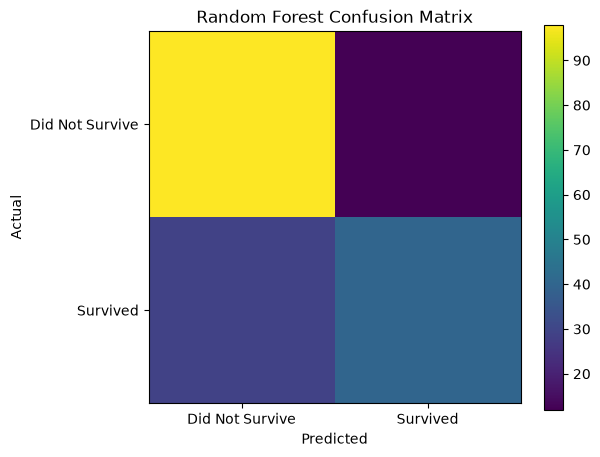

In [42]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

plt.yticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

plt.colorbar()

plt.show()

In [43]:
print(
    classification_report(
        y_test.numpy(),
        y_pred.numpy(),
        target_names=[
            "Did Not Survive",
            "Survived"
        ]
    )
)

                 precision    recall  f1-score   support

Did Not Survive       0.77      0.89      0.83       110
       Survived       0.77      0.58      0.66        69

       accuracy                           0.77       179
      macro avg       0.77      0.74      0.74       179
   weighted avg       0.77      0.77      0.76       179



In [44]:
tree_counts = [
    1,
    5,
    10,
    25,
    50
]

accuracies = []

for n_trees in tree_counts:

    forest = build_random_forest(
        X_train,
        y_train,
        n_trees=n_trees,
        max_depth=6,
        max_features=2
    )

    y_pred = random_forest_predict(
        forest,
        X_test
    )

    accuracy = (
        y_pred == y_test
    ).float().mean().item()

    accuracies.append(accuracy)

    print(
        f"{n_trees} trees → "
        f"Accuracy: {accuracy:.4f}"
    )

Tree 1/1 built
1 trees → Accuracy: 0.7542
Tree 1/5 built
Tree 2/5 built
Tree 3/5 built
Tree 4/5 built
Tree 5/5 built
5 trees → Accuracy: 0.8045
Tree 1/10 built
Tree 2/10 built
Tree 3/10 built
Tree 4/10 built
Tree 5/10 built
Tree 6/10 built
Tree 7/10 built
Tree 8/10 built
Tree 9/10 built
Tree 10/10 built
10 trees → Accuracy: 0.7765
Tree 1/25 built
Tree 2/25 built
Tree 3/25 built
Tree 4/25 built
Tree 5/25 built
Tree 6/25 built
Tree 7/25 built
Tree 8/25 built
Tree 9/25 built
Tree 10/25 built
Tree 11/25 built
Tree 12/25 built
Tree 13/25 built
Tree 14/25 built
Tree 15/25 built
Tree 16/25 built
Tree 17/25 built
Tree 18/25 built
Tree 19/25 built
Tree 20/25 built
Tree 21/25 built
Tree 22/25 built
Tree 23/25 built
Tree 24/25 built
Tree 25/25 built
25 trees → Accuracy: 0.8101
Tree 1/50 built
Tree 2/50 built
Tree 3/50 built
Tree 4/50 built
Tree 5/50 built
Tree 6/50 built
Tree 7/50 built
Tree 8/50 built
Tree 9/50 built
Tree 10/50 built
Tree 11/50 built
Tree 12/50 built
Tree 13/50 built
Tree 14/50 

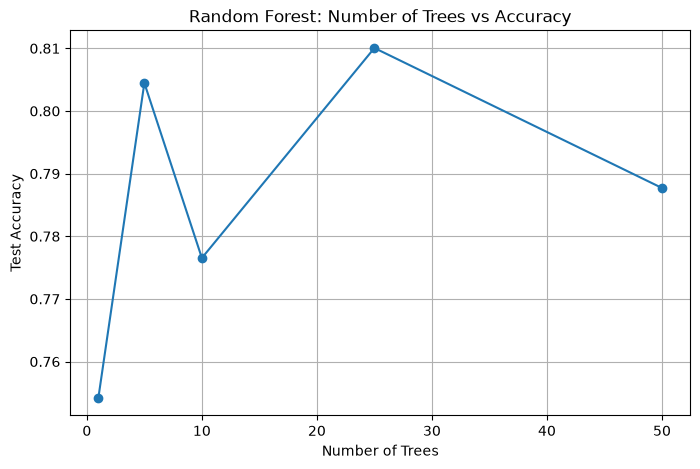

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(
    tree_counts,
    accuracies,
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("Test Accuracy")

plt.title(
    "Random Forest: "
    "Number of Trees vs Accuracy"
)

plt.grid()

plt.show()

In [46]:
single_tree = build_tree(
    X_train,
    y_train,
    max_depth=6,
    max_features=2
)

tree_pred = predict_tree(
    single_tree,
    X_test
)

tree_accuracy = (
    tree_pred == y_test
).float().mean().item()

print(
    f"Single Tree Accuracy: "
    f"{tree_accuracy:.4f}"
)

Single Tree Accuracy: 0.7039


In [47]:
forest = build_random_forest(
    X_train,
    y_train,
    n_trees=50,
    max_depth=6,
    max_features=2
)

forest_pred = random_forest_predict(
    forest,
    X_test
)

forest_accuracy = (
    forest_pred == y_test
).float().mean().item()

print(
    f"Random Forest Accuracy: "
    f"{forest_accuracy:.4f}"
)

Tree 1/50 built
Tree 2/50 built
Tree 3/50 built
Tree 4/50 built
Tree 5/50 built
Tree 6/50 built
Tree 7/50 built
Tree 8/50 built
Tree 9/50 built
Tree 10/50 built
Tree 11/50 built
Tree 12/50 built
Tree 13/50 built
Tree 14/50 built
Tree 15/50 built
Tree 16/50 built
Tree 17/50 built
Tree 18/50 built
Tree 19/50 built
Tree 20/50 built
Tree 21/50 built
Tree 22/50 built
Tree 23/50 built
Tree 24/50 built
Tree 25/50 built
Tree 26/50 built
Tree 27/50 built
Tree 28/50 built
Tree 29/50 built
Tree 30/50 built
Tree 31/50 built
Tree 32/50 built
Tree 33/50 built
Tree 34/50 built
Tree 35/50 built
Tree 36/50 built
Tree 37/50 built
Tree 38/50 built
Tree 39/50 built
Tree 40/50 built
Tree 41/50 built
Tree 42/50 built
Tree 43/50 built
Tree 44/50 built
Tree 45/50 built
Tree 46/50 built
Tree 47/50 built
Tree 48/50 built
Tree 49/50 built
Tree 50/50 built
Random Forest Accuracy: 0.7877
